In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
model = joblib.load("../models/logistic_regression_model.pkl")

In [3]:
test_df = pd.read_csv("../data/processed/test_scaled.csv")

In [4]:
X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [5]:
y_pred = model.predict(X_test)

In [6]:
y_prob = model.predict_proba(X_test)[:, 1]

In [7]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8045


In [8]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[918 115]
 [160 214]]


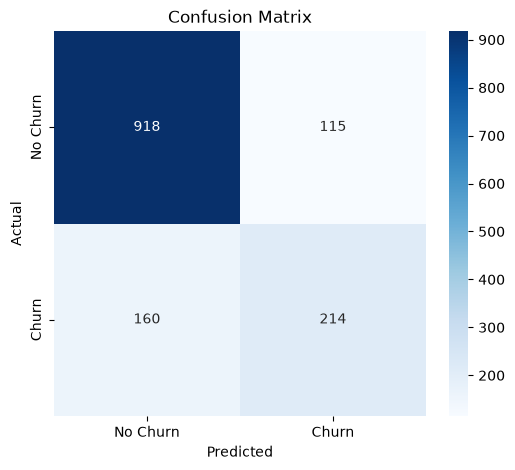

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [11]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

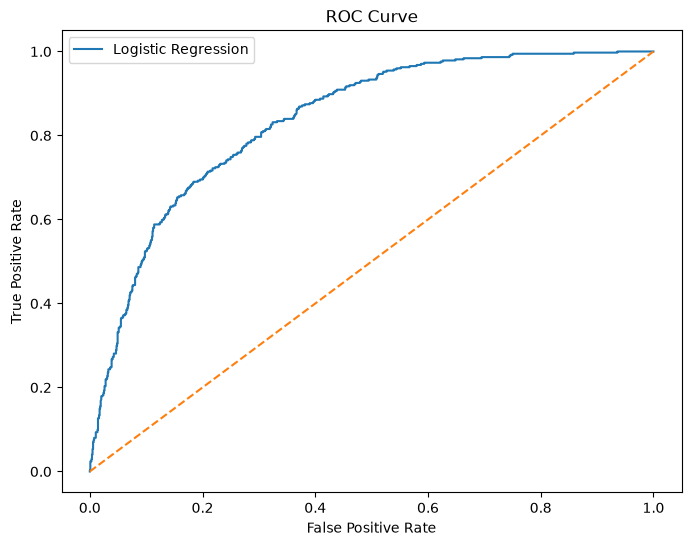

In [12]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [13]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.8361


In [14]:
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Coefficient": model.coef_[0]
})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(15)

,Feature,Coefficient,Absolute
1,tenure,-1.355817,1.355817
25,Contract_Two year,-1.351225,1.351225
10,InternetService_Fiber optic,1.121685,1.121685
24,Contract_One year,-0.743489,0.743489
3,TotalCharges,0.641811,0.641811
7,PhoneService_Yes,-0.522947,0.522947
2,MonthlyCharges,-0.445174,0.445174
28,PaymentMethod_Electronic check,0.386286,0.386286
21,StreamingTV_Yes,0.374880,0.374880
13,OnlineSecurity_Yes,-0.370820,0.370820


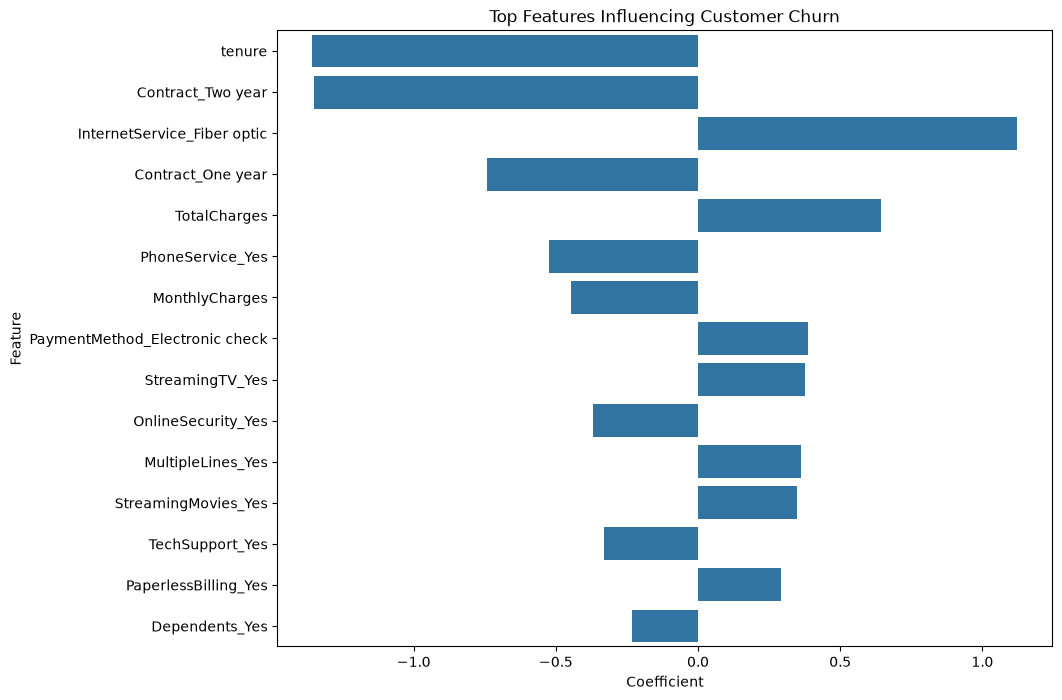

In [15]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Customer Churn")

plt.show()

In [17]:
import joblib

model = joblib.load("../models/best_logistic_model.pkl")

print(type(model))
print(model)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
LogisticRegression(C=0.1, max_iter=1000, penalty='l2', random_state=42)


In [18]:
print(model.feature_names_in_)

['SeniorCitizen' 'tenure' 'MonthlyCharges' 'TotalCharges' 'gender_Male'
 'Partner_Yes' 'Dependents_Yes' 'PhoneService_Yes'
 'MultipleLines_No phone service' 'MultipleLines_Yes'
 'InternetService_Fiber optic' 'InternetService_No'
 'OnlineSecurity_No internet service' 'OnlineSecurity_Yes'
 'OnlineBackup_No internet service' 'OnlineBackup_Yes'
 'DeviceProtection_No internet service' 'DeviceProtection_Yes'
 'TechSupport_No internet service' 'TechSupport_Yes'
 'StreamingTV_No internet service' 'StreamingTV_Yes'
 'StreamingMovies_No internet service' 'StreamingMovies_Yes'
 'Contract_One year' 'Contract_Two year' 'PaperlessBilling_Yes'
 'PaymentMethod_Credit card (automatic)' 'PaymentMethod_Electronic check'
 'PaymentMethod_Mailed check']


In [19]:
print(len(model.feature_names_in_))

30
